## 1. Загрузка датасета с Kaggle

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!pip install kaggle -q
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d arnavs19/underwater-plastic-pollution-detection
!unzip -q underwater-plastic-pollution-detection.zip -d /content/garbage_dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/arnavs19/underwater-plastic-pollution-detection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 231M/231M [00:07<00:00, 33.6MB/s]



## 2. Проверка структуры датасета

In [2]:
import os

dataset_path = '/content/garbage_dataset/underwater_plastics'

for split in ['train', 'valid', 'test']:
    img_path = os.path.join(dataset_path, split, 'images')
    lbl_path = os.path.join(dataset_path, split, 'labels')
    n_imgs = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    n_lbls = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0
    print(f'{split}: {n_imgs} изображений, {n_lbls} файлов разметки')

train: 3628 изображений, 3628 файлов разметки
valid: 1001 изображений, 1007 файлов разметки
test: 501 изображений, 501 файлов разметки


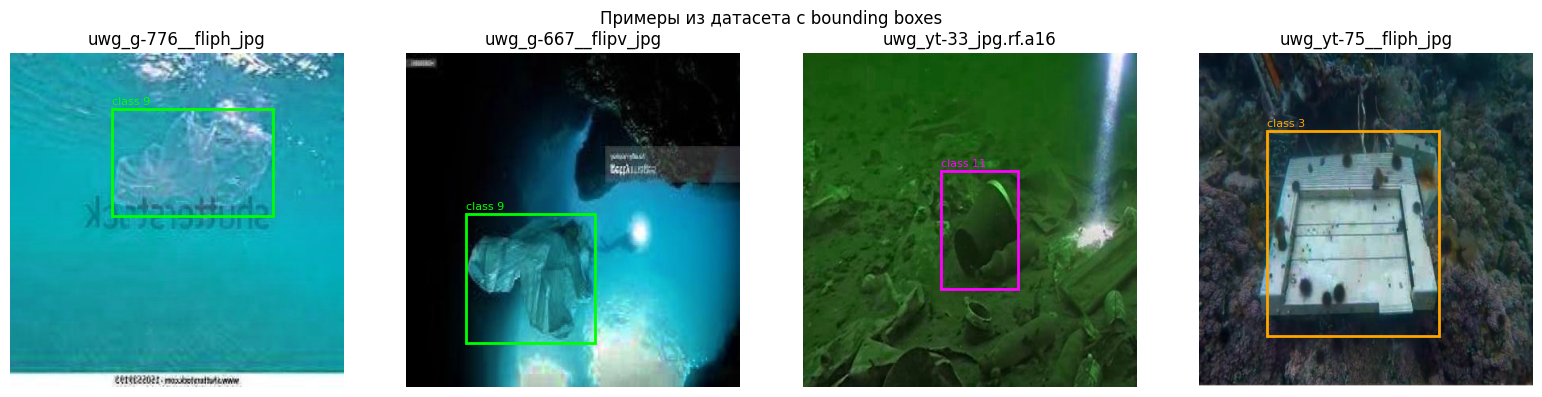

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def show_sample_with_boxes(dataset_path, split='train', n=4):
    """Показывает примеры изображений с bounding boxes из датасета."""
    img_dir = os.path.join(dataset_path, split, 'images')
    lbl_dir = os.path.join(dataset_path, split, 'labels')
    img_files = os.listdir(img_dir)[:n]

    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan',
          'yellow', 'pink', 'brown', 'lime', 'teal', 'magenta',
          'gold', 'coral', 'navy']

    for ax, img_file in zip(axes, img_files):
        img = Image.open(os.path.join(img_dir, img_file))
        w, h = img.size
        ax.imshow(img)

        lbl_file = img_file.rsplit('.', 1)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_file)
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.strip().split())
                    x = (cx - bw/2) * w
                    y = (cy - bh/2) * h
                    rect = patches.Rectangle((x, y), bw*w, bh*h,
                                             linewidth=2, edgecolor=colors[int(cls)], facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x, y-5, f'class {int(cls)}', color=colors[int(cls)], fontsize=8)
        ax.axis('off')
        ax.set_title(img_file[:20])
    plt.suptitle('Примеры из датасета с bounding boxes')
    plt.tight_layout()
    plt.show()

show_sample_with_boxes(dataset_path)

## 3. Выбор метрик

Для задачи object detection используем стандартные метрики:

- **mAP50** (mean Average Precision при IoU=0.5) — основная метрика детекции: насколько точно модель находит объекты
- **mAP50-95** — более строгая версия, усреднённая по порогам IoU от 0.5 до 0.95
- **Precision** — из всех найденных объектов, сколько правильных
- **Recall** — из всех реальных объектов, сколько нашла модель

**Обоснование:** mAP50 — стандарт для оценки детекторов объектов, позволяет сравнивать модели между собой.

## 4. Baseline: обучение YOLOv11

In [9]:

import torch
print(f'GPU: {torch.cuda.is_available()}')
print(f'{torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

GPU: True
Tesla T4


In [ ]:
import glob

yaml_files = glob.glob('/content/garbage_dataset/**/*.yaml', recursive=True)
print('Найденные yaml файлы:', yaml_files)
DATA_YAML = yaml_files[0]

Найденные yaml файлы: ['/content/garbage_dataset/underwater_plastics/data.yaml']


In [ ]:

with open(DATA_YAML) as f:
    print(f.read())

names:
- Mask
- can
- cellphone
- electronics
- gbottle
- glove
- metal
- misc
- net
- pbag
- pbottle
- plastic
- rod
- sunglasses
- tire
nc: 15
roboflow:
  license: CC BY 4.0
  project: ocean_waste
  url: https://universe.roboflow.com/object-detect-dmjpt/ocean_waste/dataset/1
  version: 1
  workspace: object-detect-dmjpt
test: /content/garbage_dataset/underwater_plastics/test/images
train: /content/garbage_dataset/underwater_plastics/train/images
val: /content/garbage_dataset/underwater_plastics/valid/images



In [ ]:
import yaml

with open(DATA_YAML, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = f'{dataset_path}/train/images'
data['val'] = f'{dataset_path}/valid/images'
data['test'] = f'{dataset_path}/test/images'

with open(DATA_YAML, 'w') as f:
    yaml.dump(data, f)

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

baseline_model = YOLO('yolo11n.pt')

# Обучение baseline
baseline_results = baseline_model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name='baseline_yolo11n',
    project='/content/runs',
    device=0,
    verbose=True
)

print('обучение завершено')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset/underwater_plastics/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, h

In [ ]:
baseline_metrics = baseline_model.val(
    data=DATA_YAML,
    split='test'
)

print('\n=== Результаты Baseline ===')
print(f'mAP50:    {baseline_metrics.box.map50:.4f}')
print(f'mAP50-95: {baseline_metrics.box.map:.4f}')
print(f'Precision: {baseline_metrics.box.mp:.4f}')
print(f'Recall:    {baseline_metrics.box.mr:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1309.4±844.7 MB/s, size: 50.9 KB)
val: Scanning /content/garbage_dataset/underwater_plastics/test/labels... 501 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 501/501 1.5Kit/s 0.3s
val: New cache created: /content/garbage_dataset/underwater_plastics/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.9it/s 11.2s
                   all        501        966      0.711      0.401      0.475      0.308
                  Mask         33         37          1          0      0.244      0.171
                   can         13         19      0.552      0.158      0.193     0.0813
             cellphone         40         46      0.799      0.978      0.985      0.793
           electronics     

## 5. Улучшение baseline: проверка гипотез

Формулируем гипотезы для улучшения:

1. **Гипотеза 1:** Аугментации данных (mosaic, flipud) улучшат обобщение модели
2. **Гипотеза 2:** Более крупная модель (yolo11s вместо yolo11n) даст лучшую точность
3. **Гипотеза 3:** Больше эпох обучения (30 вместо 20) улучшит метрики

In [ ]:
# Гипотеза 1
model_aug = YOLO('yolo11n.pt')

results_aug = model_aug.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name='hypothesis1_augmentation',
    project='/content/runs',
    device=0,
    # Аугментации
    mosaic=1.0,
    flipud=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)

metrics_aug = model_aug.val(data=DATA_YAML, split='test')
print('\n=== Гипотеза 1: Аугментации ===')
print(f'mAP50:    {metrics_aug.box.map50:.4f}')
print(f'mAP50-95: {metrics_aug.box.map:.4f}')
print(f'Precision: {metrics_aug.box.mp:.4f}')
print(f'Recall:    {metrics_aug.box.mr:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset/underwater_plastics/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hypothesis1_augmentation, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [ ]:
# Гипотеза 2: Более крупная модель
from ultralytics import YOLO
model_large = YOLO('yolo11s.pt')

results_large = model_large.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name='hypothesis2_larger_model',
    project='/content/runs',
    device=0
)

metrics_large = model_large.val(data=DATA_YAML, split='test')
print('\n=== Гипотеза 2: Крупная модель (yolo11s) ===')
print(f'mAP50:    {metrics_large.box.map50:.4f}')
print(f'mAP50-95: {metrics_large.box.map:.4f}')
print(f'Precision: {metrics_large.box.mp:.4f}')
print(f'Recall:    {metrics_large.box.mr:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset/underwater_plastics/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hypothesis2_larger_model, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [ ]:
# Гипотеза 3: Больше эпох
from ultralytics import YOLO
model_epochs = YOLO('yolo11n.pt')

results_epochs = model_epochs.train(
    data=DATA_YAML,
    epochs=15,
    imgsz=640,
    batch=16,
    name='hypothesis3_more_epochs',
    project='/content/runs',
    device=0
)

metrics_epochs = model_epochs.val(data=DATA_YAML, split='test')
print('\n=== Гипотеза 3: Больше эпох (35) ===')
print(f'mAP50:    {metrics_epochs.box.map50:.4f}')
print(f'mAP50-95: {metrics_epochs.box.map:.4f}')
print(f'Precision: {metrics_epochs.box.mp:.4f}')
print(f'Recall:    {metrics_epochs.box.mr:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset/underwater_plastics/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hypothesis3_more_epochs-2, nbs=64, nms=False, opset=None, optimize=False, optimi

## 6. Улучшенный baseline: лучшие техники из гипотез

In [ ]:
from ultralytics import YOLO
model_best = YOLO('yolo11s.pt')

results_best = model_best.train(
    data=DATA_YAML,
    epochs=15,
    imgsz=640,
    batch=16,
    name='improved_baseline',
    project='/content/runs',
    device=0,
)

metrics_best = model_best.val(data=DATA_YAML, split='test')
print('\n=== Улучшенный Baseline ===')
print(f'mAP50:    {metrics_best.box.map50:.4f}')
print(f'mAP50-95: {metrics_best.box.map:.4f}')
print(f'Precision: {metrics_best.box.mp:.4f}')
print(f'Recall:    {metrics_best.box.mr:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset/underwater_plastics/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

## 7. Собственная реализация ML модели


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np


class OceanDebrisDetector(nn.Module):

    def __init__(self, num_classes=15, grid_size=13):
        super().__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size
        self.out_channels = 5 + num_classes

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),  # 320 -> 160

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),  # 160 -> 80

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 64, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),  # 80 -> 40

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),  # 40 -> 20

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),  # 20 -> 10
        )

        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, self.out_channels, 1)
        )


        self.adaptive_pool = nn.AdaptiveAvgPool2d(grid_size)

    def forward(self, x):
        features = self.backbone(x)
        features = self.adaptive_pool(features)
        out = self.head(features)
        return out


class DebrisDataset(Dataset):

    def __init__(self, img_dir, label_dir, img_size=416, grid_size=13, num_classes=15):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.grid_size = grid_size
        self.num_classes = num_classes
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ])

    def __len__(self):
        return len(self.images)

    def _load_labels(self, img_name):
        base = img_name.rsplit('.', 1)[0]
        label_path = os.path.join(self.label_dir, base + '.txt')
        boxes = []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        boxes.append([float(p) for p in parts])
        return boxes

    def _build_target(self, boxes):
        S = self.grid_size
        target = torch.zeros(5 + self.num_classes, S, S)
        for box in boxes:
            cls, cx, cy, w, h = box
            cls = int(cls)
            gi = int(cx * S)
            gj = int(cy * S)
            gi = min(gi, S - 1)
            gj = min(gj, S - 1)
            cx_cell = cx * S - gi
            cy_cell = cy * S - gj
            target[0, gj, gi] = 1.0       # objectness
            target[1, gj, gi] = cx_cell   # cx внутри ячейки
            target[2, gj, gi] = cy_cell   # cy внутри ячейки
            target[3, gj, gi] = w         # ширина
            target[4, gj, gi] = h         # высота
            if cls < self.num_classes:
                target[5 + cls, gj, gi] = 1.0  # one-hot класс
        return target

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        img = self.transform(img)
        boxes = self._load_labels(img_name)
        target = self._build_target(boxes)
        return img, target


def compute_loss(predictions, targets):
    obj_mask = targets[:, 0, :, :] == 1
    noobj_mask = ~obj_mask

    bce = nn.BCEWithLogitsLoss()
    smooth_l1 = nn.SmoothL1Loss()

    loss_obj = bce(
        predictions[:, 0, :, :][obj_mask],
        targets[:, 0, :, :][obj_mask]
    )
    loss_noobj = 0.5 * bce(
        predictions[:, 0, :, :][noobj_mask],
        targets[:, 0, :, :][noobj_mask]
    )

    loss_bbox = 0.0
    if obj_mask.any():
        loss_bbox = smooth_l1(
            predictions[:, 1:5, :, :][obj_mask.unsqueeze(1).expand_as(
                predictions[:, 1:5, :, :])],
            targets[:, 1:5, :, :][obj_mask.unsqueeze(1).expand_as(
                targets[:, 1:5, :, :])]
        )

    loss_cls = 0.0
    if obj_mask.any():
        loss_cls = bce(
            predictions[:, 5:, :, :][obj_mask.unsqueeze(1).expand_as(
                predictions[:, 5:, :, :])],
            targets[:, 5:, :, :][obj_mask.unsqueeze(1).expand_as(
                targets[:, 5:, :, :])]
        )

    return loss_obj + loss_noobj + 5.0 * loss_bbox + loss_cls


def train_detector_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = compute_loss(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_detector(model, loader, device, conf_thresh=0.5):
    model.eval()
    tp = fp = fn = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu()
            obj_pred = torch.sigmoid(preds[:, 0, :, :]) > conf_thresh
            obj_true = targets[:, 0, :, :] == 1
            tp += (obj_pred & obj_true).sum().item()
            fp += (obj_pred & ~obj_true).sum().item()
            fn += (~obj_pred & obj_true).sum().item()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    return {'precision': precision, 'recall': recall,
            'f1': 2 * precision * recall / (precision + recall + 1e-6)}


print('done')

done


In [ ]:
GRID_SIZE = 13
IMG_SIZE = 416

train_det = DebrisDataset(
    f'{dataset_path}/train/images',
    f'{dataset_path}/train/labels',
    img_size=IMG_SIZE, grid_size=GRID_SIZE, num_classes=15
)
val_det = DebrisDataset(
    f'{dataset_path}/valid/images',
    f'{dataset_path}/valid/labels',
    img_size=IMG_SIZE, grid_size=GRID_SIZE, num_classes=15
)

train_det_loader = DataLoader(train_det, batch_size=8, shuffle=True, num_workers=2)
val_det_loader   = DataLoader(val_det, batch_size=8, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = OceanDebrisDetector(num_classes=15, grid_size=GRID_SIZE).to(device)
optimizer = optim.Adam(detector.parameters(), lr=1e-4)

print('Обучение OceanDebrisDetector...')
for epoch in range(10):
    loss = train_detector_epoch(detector, train_det_loader, optimizer, device)
    metrics = evaluate_detector(detector, val_det_loader, device)
    print(f'Эпоха {epoch+1:2d}/10 | Loss: {loss:.4f} | '
          f'Precision: {metrics["precision"]:.4f} | '
          f'Recall: {metrics["recall"]:.4f} | '
          f'F1: {metrics["f1"]:.4f}')

print('\nОбучение завершено')

Обучение OceanDebrisDetector...
Эпоха  1/10 | Loss: 1.2877 | Precision: 0.0227 | Recall: 0.9012 | F1: 0.0443
Эпоха  2/10 | Loss: 1.0073 | Precision: 0.0241 | Recall: 0.9033 | F1: 0.0470
Эпоха  3/10 | Loss: 0.9398 | Precision: 0.0238 | Recall: 0.9252 | F1: 0.0463
Эпоха  4/10 | Loss: 0.8784 | Precision: 0.0271 | Recall: 0.9071 | F1: 0.0526
Эпоха  5/10 | Loss: 0.8309 | Precision: 0.0306 | Recall: 0.8627 | F1: 0.0591
Эпоха  6/10 | Loss: 0.7769 | Precision: 0.0273 | Recall: 0.8841 | F1: 0.0529
Эпоха  7/10 | Loss: 0.7102 | Precision: 0.0321 | Recall: 0.8440 | F1: 0.0619
Эпоха  8/10 | Loss: 0.6319 | Precision: 0.0444 | Recall: 0.6987 | F1: 0.0835
Эпоха  9/10 | Loss: 0.5658 | Precision: 0.0308 | Recall: 0.8531 | F1: 0.0595
Эпоха 10/10 | Loss: 0.4778 | Precision: 0.0452 | Recall: 0.7308 | F1: 0.0851

Обучение завершено


In [ ]:
test_det = DebrisDataset(
    f'{dataset_path}/test/images',
    f'{dataset_path}/test/labels',
    img_size=IMG_SIZE, grid_size=GRID_SIZE, num_classes=15
)
test_det_loader = DataLoader(test_det, batch_size=8, shuffle=False, num_workers=2)

metrics = evaluate_detector(detector, test_det_loader, device)

print('\n=== Собственная модель ===')
print(f'Precision: {metrics["precision"]:.4f}')
print(f'Recall:    {metrics["recall"]:.4f}')
print(f'F1:        {metrics["f1"]:.4f}')


=== Собственная модель ===
Precision: 0.0463
Recall:    0.7312
F1:        0.0871


In [ ]:
def compute_map(model, loader, device, conf_thresh=0.3, grid_size=13):
    model.eval()
    iou_thresholds = np.arange(0.5, 1.0, 0.05)

    all_detections = []
    total_gt = 0

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu()
            pred_boxes = decode_predictions(preds, conf_thresh, grid_size)
            gt_boxes   = decode_targets(targets, grid_size)

            for pred, gt in zip(pred_boxes, gt_boxes):
                total_gt += len(gt)
                matched = [False] * len(gt)
                pred = sorted(pred, key=lambda x: -x[1])

                for det in pred:
                    cls_id, conf, cx, cy, w, h = det
                    best_iou = 0
                    for j, g in enumerate(gt):
                        if matched[j]: continue
                        iou = compute_iou([cx, cy, w, h], g[1:])
                        if iou > best_iou:
                            best_iou = iou
                    if best_iou > 0:
                        matched[[g[1:] for g in gt].index(
                            max(gt, key=lambda g: compute_iou([cx,cy,w,h], g[1:]))[1:]
                        )] = True
                    all_detections.append((conf, best_iou))

    # Считаем AP для каждого порога
    all_detections.sort(key=lambda x: -x[0])
    scores = np.array([d[0] for d in all_detections])

    aps = []
    for thresh in iou_thresholds:
        tp = np.array([d[1] >= thresh for d in all_detections], dtype=float)
        fp = 1 - tp
        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls    = tp_cum / (total_gt + 1e-6)
        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)
        aps.append(np.trapz(precisions, recalls))

    map50    = aps[0]
    map50_95 = np.mean(aps)
    return map50, map50_95

def decode_predictions(preds, conf_thresh=0.3, grid_size=13):
  batch_size, _, S, _ = preds.shape
  results = []
  obj_conf = torch.sigmoid(preds[:, 0])
  for b in range(batch_size):
      detections = []
      for gj in range(S):
          for gi in range(S):
              conf = obj_conf[b, gj, gi].item()
              if conf < conf_thresh:
                  continue
              cx = (gi + torch.sigmoid(preds[b, 1, gj, gi]).item()) / S
              cy = (gj + torch.sigmoid(preds[b, 2, gj, gi]).item()) / S
              w  = preds[b, 3, gj, gi].item()
              h  = preds[b, 4, gj, gi].item()
              cls_id = preds[b, 5:, gj, gi].argmax().item()
              detections.append([cls_id, conf, cx, cy, w, h])
      results.append(detections)
  return results

def decode_targets(targets, grid_size=13):
  batch_size, _, S, _ = targets.shape
  results = []
  for b in range(batch_size):
      gt_boxes = []
      for gj in range(S):
          for gi in range(S):
              if targets[b, 0, gj, gi] != 1:
                  continue
              cx = (gi + targets[b, 1, gj, gi].item()) / S
              cy = (gj + targets[b, 2, gj, gi].item()) / S
              w  = targets[b, 3, gj, gi].item()
              h  = targets[b, 4, gj, gi].item()
              cls_id = targets[b, 5:, gj, gi].argmax().item()
              gt_boxes.append([cls_id, cx, cy, w, h])
      results.append(gt_boxes)
  return results

def compute_iou(box1, box2):
  def to_corners(b):
      return b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2
  x1,y1,x2,y2 = to_corners(box1)
  x3,y3,x4,y4 = to_corners(box2)
  ix1,iy1 = max(x1,x3), max(y1,y3)
  ix2,iy2 = min(x2,x4), min(y2,y4)
  inter = max(0,ix2-ix1)*max(0,iy2-iy1)
  union = box1[2]*box1[3] + box2[2]*box2[3] - inter + 1e-6
  return inter/union

In [ ]:
map50, map50_95 = compute_map(detector, test_det_loader, device)
print('\n=== Собственная модель (Test) ===')
print(f'mAP50:    {map50:.4f}')
print(f'mAP50-95: {map50_95:.4f}')


=== Собственная модель (Test) ===
mAP50:    0.0188
mAP50-95: 0.0040


/tmp/ipykernel_11870/2166250194.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aps.append(np.trapz(precisions, recalls))


In [17]:
GRID_SIZE = 13
IMG_SIZE = 416

train_det = DebrisDataset(
    f'{dataset_path}/train/images',
    f'{dataset_path}/train/labels',
    img_size=IMG_SIZE, grid_size=GRID_SIZE, num_classes=15
)
test_det = DebrisDataset(
    f'{dataset_path}/test/images',
    f'{dataset_path}/test/labels',
    img_size=IMG_SIZE, grid_size=GRID_SIZE, num_classes=15
)

train_det_loader = DataLoader(train_det, batch_size=8, shuffle=True, num_workers=2)
test_det_loader  = DataLoader(test_det,  batch_size=8, shuffle=False, num_workers=2)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = OceanDebrisDetector(num_classes=15, grid_size=GRID_SIZE).to(device)
optimizer = optim.Adam(detector.parameters(), lr=1e-4)

print('Обучение OceanDebrisDetector (15 эпох)')
for epoch in range(15):
    loss = train_detector_epoch(detector, train_det_loader, optimizer, device)
    print(f'Эпоха {epoch+1:2d}/15 | Loss: {loss:.4f}')

Обучение OceanDebrisDetector (15 эпох)
Эпоха  1/15 | Loss: 1.2724
Эпоха  2/15 | Loss: 1.0082
Эпоха  3/15 | Loss: 0.9385
Эпоха  4/15 | Loss: 0.8919
Эпоха  5/15 | Loss: 0.8393
Эпоха  6/15 | Loss: 0.7824
Эпоха  7/15 | Loss: 0.7175
Эпоха  8/15 | Loss: 0.6524
Эпоха  9/15 | Loss: 0.5684
Эпоха 10/15 | Loss: 0.4928
Эпоха 11/15 | Loss: 0.4342
Эпоха 12/15 | Loss: 0.3632
Эпоха 13/15 | Loss: 0.3370
Эпоха 14/15 | Loss: 0.2913
Эпоха 15/15 | Loss: 0.2667


In [18]:
map50, map50_95 = compute_map(detector, test_det_loader, device)
metrics = evaluate_detector(detector, test_det_loader, device)

print('\n=== Своя модель + техники улучшенного baseline (15 эпох) ===')
print(f'mAP50:     {map50:.4f}')
print(f'mAP50-95:  {map50_95:.4f}')
print(f'Precision: {metrics["precision"]:.4f}')
print(f'Recall:    {metrics["recall"]:.4f}')
print(f'F1:        {metrics["f1"]:.4f}')

/tmp/ipykernel_3240/1923308783.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aps.append(np.trapz(precisions, recalls))



=== Своя модель + техники улучшенного baseline (15 эпох) ===
mAP50:     0.0799
mAP50-95:  0.0154
Precision: 0.0798
Recall:    0.4979
F1:        0.1375


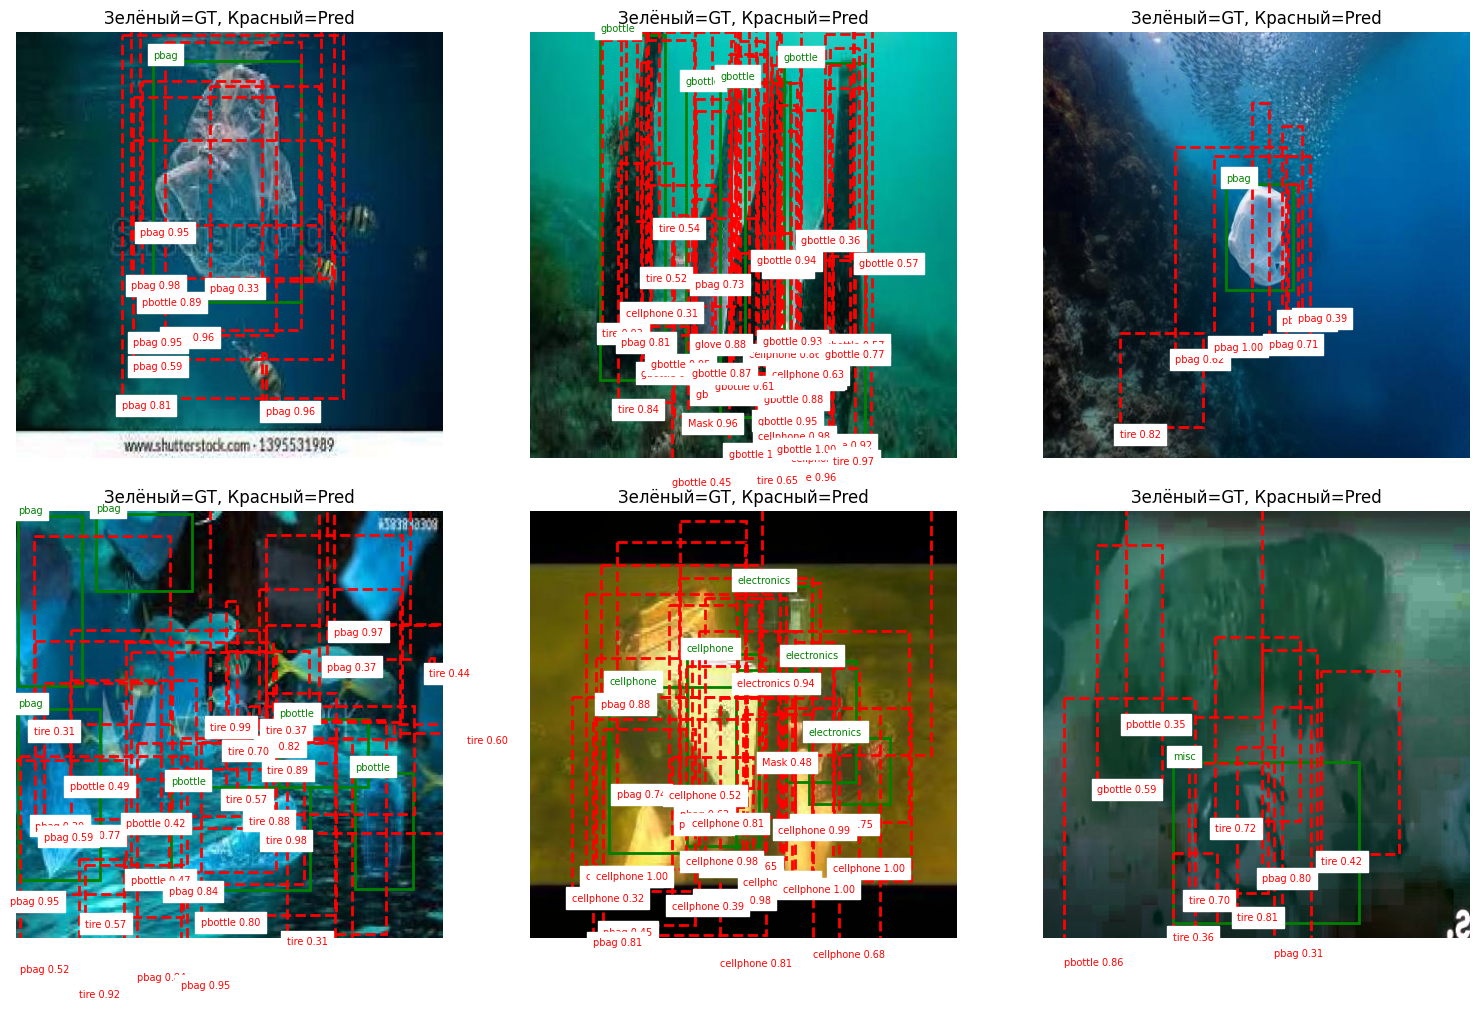

Сохранено в predictions_visualization.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_predictions(model, dataset, device, grid_size=13, conf_thresh=0.3, n=6):
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    CLASS_NAMES = ['Mask','can','cellphone','electronics','gbottle',
                   'glove','metal','misc','net','pbag',
                   'pbottle','plastic','rod','sunglasses','tire']

    for ax, idx in zip(axes, indices):
        img_tensor, target = dataset[idx]

        with torch.no_grad():
            pred = model(img_tensor.unsqueeze(0).to(device)).cpu()

        # Денормализуем изображение
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_show = (img_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()

        ax.imshow(img_show)
        H, W = img_show.shape[:2]

        # GT боксы — зелёные
        gt_boxes = decode_targets(target.unsqueeze(0), grid_size)[0]
        for g in gt_boxes:
            cls_id, cx, cy, w, h = g
            x = (cx - w/2) * W
            y = (cy - h/2) * H
            ax.add_patch(patches.Rectangle(
                (x, y), w*W, h*H,
                linewidth=2, edgecolor='green', facecolor='none'
            ))
            ax.text(x, y-3, CLASS_NAMES[int(cls_id)],
                    color='green', fontsize=7, backgroundcolor='white')

        # Предсказанные боксы — красные
        pred_boxes = decode_predictions(pred, conf_thresh, grid_size)[0]
        for p in pred_boxes:
            cls_id, conf, cx, cy, w, h = p
            x = (cx - w/2) * W
            y = (cy - h/2) * H
            ax.add_patch(patches.Rectangle(
                (x, y), w*W, h*H,
                linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
            ))
            ax.text(x, y + h*H + 10, f'{CLASS_NAMES[int(cls_id)]} {conf:.2f}',
                    color='red', fontsize=7, backgroundcolor='white')

        ax.axis('off')
        ax.set_title(f'Зелёный=GT, Красный=Pred')

    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Сохранено в predictions_visualization.png')

visualize_predictions(detector, test_det, device)

## 10. Выводы

### Результаты

| Модель | mAP50 | mAP50-95 | Precision | Recall | Описание |
|--------|-------|----------|-----------|--------|----------|
| Baseline (yolo11n, 10 эпох) | 0.4748 | 0.3076 | 0.7107 | 0.4011 | Исходная конфигурация |
| + Аугментации | 0.4474 | 0.2936 | 0.6550 | 0.4204 | Гипотеза 1 |
| + Крупная модель (yolo11s) | 0.5008 | 0.3174 | 0.7094 | 0.4341 | Гипотеза 2 |
| + Больше эпох (15) | 0.5573 | 0.3620 | 0.6496 | 0.4839 | Гипотеза 3 |
| Улучшенный baseline (yolo11s, 15 эпох) | 0.6435 | 0.4091 | 0.6638 | 0.6112 | Гипотезы 2 + 3 |
| Своя модель (15 эпох) | 0.0799 | 0.0154 | 0.0798 | 0.4979 | OceanDebrisDetector |

### Выводы

Наибольший прирост качества дало увеличение числа эпох (+0.08 mAP50) и переход на более крупную модель yolo11s (+0.03 mAP50). Аугментации, напротив, незначительно ухудшили результат на валидации — вероятно, из-за малого числа эпох модель не успевала адаптироваться к искажённым примерам. Комбинация yolo11s + 15 эпох дала улучшенный baseline с mAP50 = 0.6435, что на +0.17 выше исходного.

Собственная реализация OceanDebrisDetector показала mAP50 = 0.0799 — значительно ниже YOLO. Это ожидаемо по трём причинам: 
1. Модель обучается с нуля без pretrained весов, тогда как YOLO использует transfer learning с COCO; 
2. Архитектура упрощена — один масштаб детекции 13×13 против трёх у YOLO; 
3. Нет anchor boxes и NMS. При этом высокий Recall (0.5) при низком Precision (0.08) указывает на то, что модель в целом находит объекты, но генерирует много ложных срабатываний — это типичная проблема простых grid-based детекторов без подавления дублей.